In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

In [23]:
OUTPUT_PATH = Path("../output")
DATA_PATH = Path("../data")

In [24]:
X = np.load(OUTPUT_PATH / "X_reduced_5.npy")
df_train = pd.read_csv(DATA_PATH / "UNSW_NB15_training-set.csv")
y_true = df_train["label"]

print(
    f"Données prêtes pour le clustering : {X.shape[0]} échantillons, {X.shape[0]} colonnes."
)

Données prêtes pour le clustering : 82332 échantillons, 82332 colonnes.


In [25]:
list_k = range(2, 11)
ari_scores = []
mri_scores = []
inertias = []

for k in list_k:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X)

    inertias.append(km.inertia_)
    ari_scores.append(adjusted_rand_score(y_true, labels))
    mri_scores.append(normalized_mutual_info_score(y_true, labels))

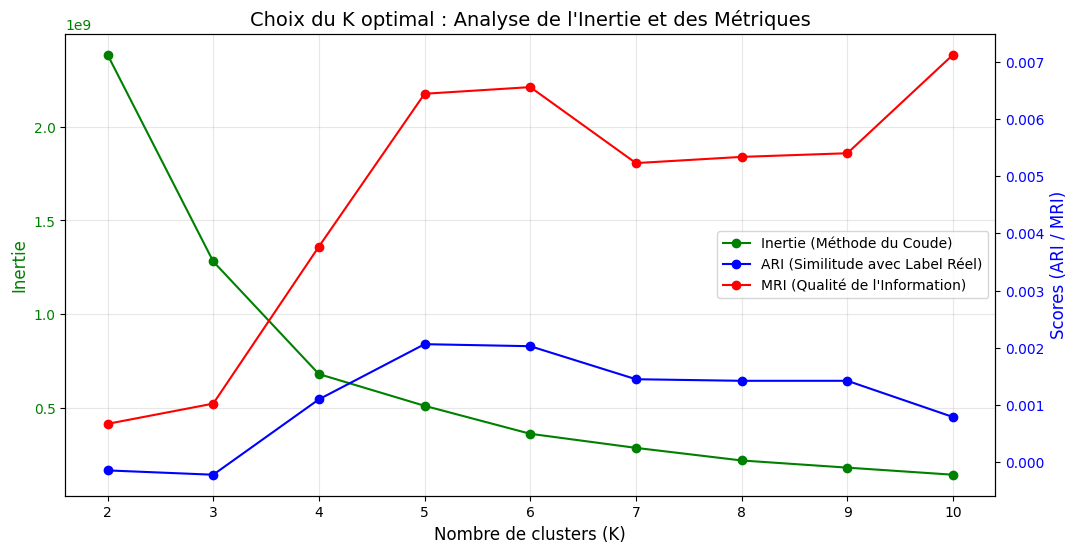

In [26]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(list_k, inertias, "go-", label="Inertie (Méthode du Coude)")
ax1.set_xlabel("Nombre de clusters (K)", fontsize=12)
ax1.set_ylabel("Inertie", color="g", fontsize=12)
ax1.tick_params(axis="y", labelcolor="g")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(list_k, ari_scores, "bo-", label="ARI (Similitude avec Label Réel)")
ax2.plot(list_k, mri_scores, "ro-", label="MRI (Qualité de l'Information)")
ax2.set_ylabel("Scores (ARI / MRI)", color="b", fontsize=12)
ax2.tick_params(axis="y", labelcolor="b")

plt.title("Choix du K optimal : Analyse de l'Inertie et des Métriques", fontsize=14)
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="center right")

plt.show()

In [34]:
n_clusters = 9
kmeans = KMeans(n_clusters=n_clusters, init="k-means++", n_init=10, random_state=42)
y_pred = kmeans.fit_predict(X)

print("-" * 32)
print(f"RÉSULTATS DU MODÈLE FINAL (K={n_clusters})")
print("-" * 32)
print(f"ARI : {adjusted_rand_score(y_true, y_pred):.4f}")
print(f"MRI : {normalized_mutual_info_score(y_true, y_pred):.4f}")
print("-" * 32)

--------------------------------
RÉSULTATS DU MODÈLE FINAL (K=9)
--------------------------------
ARI : 0.0014
MRI : 0.0054
--------------------------------


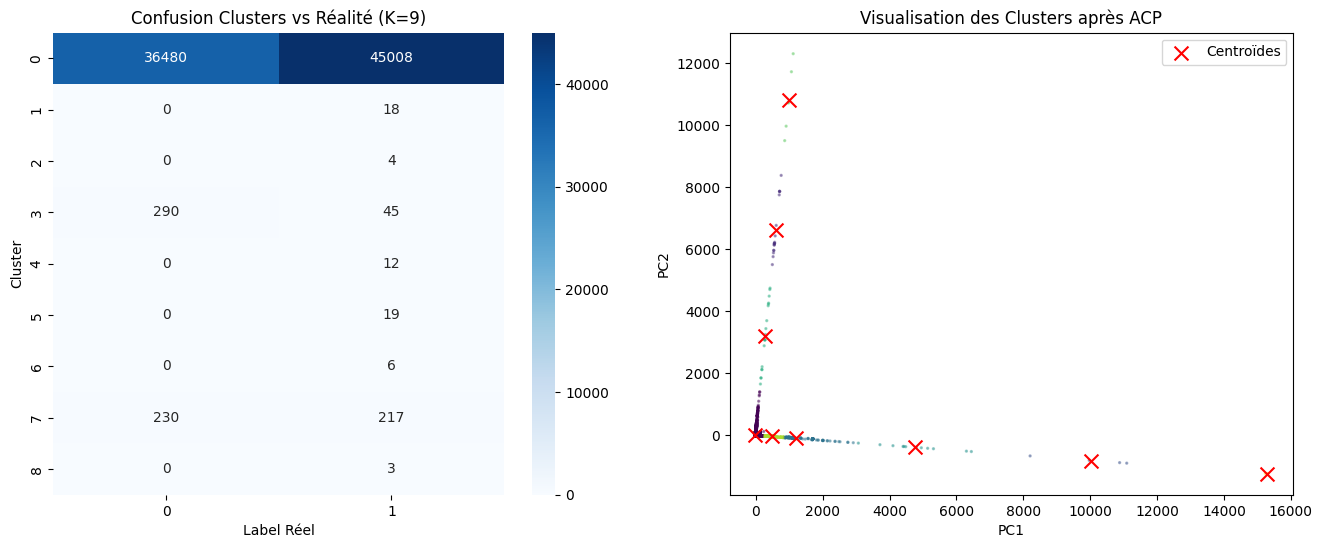

In [32]:
ct = pd.crosstab(y_pred, y_true, rownames=["Cluster"], colnames=["Label Réel"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax1)
ax1.set_title(f"Confusion Clusters vs Réalité (K={n_clusters})")

ax2.scatter(X[:, 0], X[:, 1], c=y_pred, cmap="viridis", s=2, alpha=0.4)
ax2.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c="red",
    marker="x",
    s=100,
    label="Centroïdes",
)
ax2.set_title("Visualisation des Clusters après ACP")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.legend()

plt.show()